In [1]:
# Problem Statement:

# “Using the global air quality dataset, identify which pollutants contribute most to poor air quality and understand how meteorological factors influence pollution levels. The goal is to provide actionable insights for policymakers to improve air quality, reduce health risks, and optimize pollution mitigation strategies.”

# Steps for Visualization:
# Import the required libraries.
# Perform basic operations to understand the dataset, such as df.head(), df.tail(), df.info(), df.shape, and df.describe().
# Perform data visualization on the dataset.
# Check for missing values using isnull().
# Fill the missing values using mean, or apply forward fill or backward fill methods.
# Perform visualization again after handling missing values to get clearer insights.

In [2]:
# Importing essential Python Libraries

import numpy as np#allthe arithmetic operati
import pandas as pd#dataset importing
import matplotlib.pyplot as plt# for visualizatioin
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')


In [3]:
#Import dataset
#Double backslashes-> "C:\\Users\\Name\\file.csv"
#Forward slashes-> "C:/Users/Name/file.csv"
#Raw string r"-> C:\Users\Name\file.csv" No need to double backslashes
#os.path.join() os.path.join-> ("C:", "Users", "Name", "file.csv")
#pathlib.Path Path-> ("C:/Users/Name/file.csv")
df = pd.read_csv("Downloads//global_air_quality_dataset (1).csv") 

In [4]:
df.head()# Displays the first 5 rows of the DataFrame to get a quick look at the dataset df.head()

,Date,City,Country,AQI,PM2.5 (Âµg/mÂ³),PM10 (Âµg/mÂ³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (Â°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [5]:
df.tail()# Displays the last 5 rows of the DataFrame to get a quick look at the dataset df.head()

,Date,City,Country,AQI,PM2.5 (Âµg/mÂ³),PM10 (Âµg/mÂ³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (Â°C),Humidity (%),Wind Speed (m/s)
3655,2024-12-31,Paris,France,177,224.3,143.3,62.2,44.8,1.10,58.1,25.7,15,3.8
3656,2024-12-31,Tokyo,Japan,197,215.7,140.4,74.1,33.5,5.97,116.5,-6.0,69,11.1
3657,2024-12-31,Sydney,Australia,280,53.4,47.4,32.1,36.8,5.53,68.0,22.7,41,11.0
3658,2024-12-31,SÃ£o Paulo,Brazil,229,98.8,175.9,91.1,46.8,9.39,169.1,22.5,42,2.6
3659,2024-12-31,Cairo,Egypt,192,239.8,10.2,26.3,22.9,6.03,51.5,17.0,51,12.4


In [6]:
# Generates descriptive statistics for numeric columns(count,mean,std,min,max)
df.describe()

,AQI,PM2.5 (Âµg/mÂ³),PM10 (Âµg/mÂ³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (Â°C),Humidity (%),Wind Speed (m/s)
count,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000
mean,164.642077,126.380574,154.785956,52.960710,25.940328,5.023842,105.325929,15.061913,50.657104,7.788907
std,78.571659,71.016089,84.045548,27.361413,14.001531,2.851573,55.032175,14.590761,23.195880,4.223788
min,30.000000,5.100000,10.000000,5.100000,2.000000,0.100000,10.100000,-10.000000,10.000000,0.500000
25%,96.000000,63.700000,82.200000,29.175000,13.700000,2.590000,57.900000,2.175000,31.000000,4.100000
50%,165.000000,125.850000,152.550000,52.800000,26.200000,4.910000,105.750000,15.000000,51.000000,7.800000
75%,233.000000,187.000000,227.600000,76.700000,38.200000,7.560000,152.925000,27.525000,71.000000,11.500000
max,300.000000,250.000000,300.000000,100.000000,50.000000,9.990000,200.000000,40.000000,90.000000,15.000000


In [7]:
# Displays concise summary of the DataFrame including column names, data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               3660 non-null   object 
 1   City               3660 non-null   object 
 2   Country            3660 non-null   object 
 3   AQI                3660 non-null   int64  
 4   PM2.5 (Âµg/mÂ³)    3660 non-null   float64
 5   PM10 (Âµg/mÂ³)     3660 non-null   float64
 6   NO2 (ppb)          3660 non-null   float64
 7   SO2 (ppb)          3660 non-null   float64
 8   CO (ppm)           3660 non-null   float64
 9   O3 (ppb)           3660 non-null   float64
 10  Temperature (Â°C)  3660 non-null   float64
 11  Humidity (%)       3660 non-null   int64  
 12  Wind Speed (m/s)   3660 non-null   float64
dtypes: float64(8), int64(2), object(3)
memory usage: 371.8+ KB


In [8]:
df.columns # Displays the List of all column names in the DataFrame

Index(['Date', 'City', 'Country', 'AQI', 'PM2.5 (Âµg/mÂ³)', 'PM10 (Âµg/mÂ³)',
       'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (Â°C)',
       'Humidity (%)', 'Wind Speed (m/s)'],
      dtype='object')

In [9]:
df.shape# Returns a tuple showing the number of rows and columns in the DataFrame

(3660, 13)

In [10]:
df.dtypes# Gives quick info on data types of each column 

Date                  object
City                  object
Country               object
AQI                    int64
PM2.5 (Âµg/mÂ³)      float64
PM10 (Âµg/mÂ³)       float64
NO2 (ppb)            float64
SO2 (ppb)            float64
CO (ppm)             float64
O3 (ppb)             float64
Temperature (Â°C)    float64
Humidity (%)           int64
Wind Speed (m/s)     float64
dtype: object

In [11]:
df.isnull()# Returns a DataFrame of the same shape showing True where values are missing (NaN) 

,Date,City,Country,AQI,PM2.5 (Âµg/mÂ³),PM10 (Âµg/mÂ³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (Â°C),Humidity (%),Wind Speed (m/s)
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,False,False,False,False,False,False,False,False,False,False,False,False,False
3656,False,False,False,False,False,False,False,False,False,False,False,False,False
3657,False,False,False,False,False,False,False,False,False,False,False,False,False
3658,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum() # Shows the total number of missing (NaN) values in each column

Date                 0
City                 0
Country              0
AQI                  0
PM2.5 (Âµg/mÂ³)      0
PM10 (Âµg/mÂ³)       0
NO2 (ppb)            0
SO2 (ppb)            0
CO (ppm)             0
O3 (ppb)             0
Temperature (Â°C)    0
Humidity (%)         0
Wind Speed (m/s)     0
dtype: int64

In [13]:
df.nunique()# Returns the number of unique (distinct) values present in each column of the Data 

Date                  366
City                   10
Country                 9
AQI                   271
PM2.5 (Âµg/mÂ³)      1892
PM10 (Âµg/mÂ³)       2100
NO2 (ppb)             934
SO2 (ppb)             481
CO (ppm)              970
O3 (ppb)             1629
Temperature (Â°C)     501
Humidity (%)           81
Wind Speed (m/s)      146
dtype: int64

In [14]:
df.fillna(0)# Replace all NaNs with 0

,Date,City,Country,AQI,PM2.5 (Âµg/mÂ³),PM10 (Âµg/mÂ³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (Â°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,2024-12-31,Paris,France,177,224.3,143.3,62.2,44.8,1.10,58.1,25.7,15,3.8
3656,2024-12-31,Tokyo,Japan,197,215.7,140.4,74.1,33.5,5.97,116.5,-6.0,69,11.1
3657,2024-12-31,Sydney,Australia,280,53.4,47.4,32.1,36.8,5.53,68.0,22.7,41,11.0
3658,2024-12-31,SÃ£o Paulo,Brazil,229,98.8,175.9,91.1,46.8,9.39,169.1,22.5,42,2.6


In [15]:
df.fillna(method='ffill')# Fills NaNs using the previous row's value

,Date,City,Country,AQI,PM2.5 (Âµg/mÂ³),PM10 (Âµg/mÂ³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (Â°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,2024-12-31,Paris,France,177,224.3,143.3,62.2,44.8,1.10,58.1,25.7,15,3.8
3656,2024-12-31,Tokyo,Japan,197,215.7,140.4,74.1,33.5,5.97,116.5,-6.0,69,11.1
3657,2024-12-31,Sydney,Australia,280,53.4,47.4,32.1,36.8,5.53,68.0,22.7,41,11.0
3658,2024-12-31,SÃ£o Paulo,Brazil,229,98.8,175.9,91.1,46.8,9.39,169.1,22.5,42,2.6


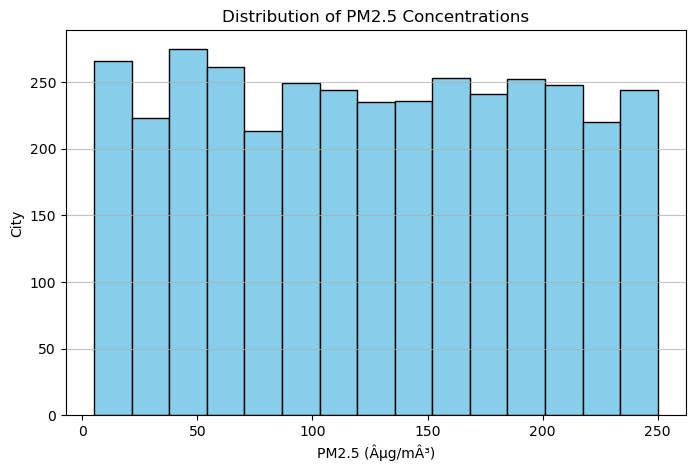

In [17]:
#Univariate Graph
#1.Histogram plot
plt.figure(figsize=(8,5))
plt.hist(df['PM2.5 (Âµg/mÂ³)'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of PM2.5 Concentrations')
plt.xlabel('PM2.5 (Âµg/mÂ³)')
plt.ylabel('City')
plt.grid(axis='y', alpha=0.75)
plt.show()

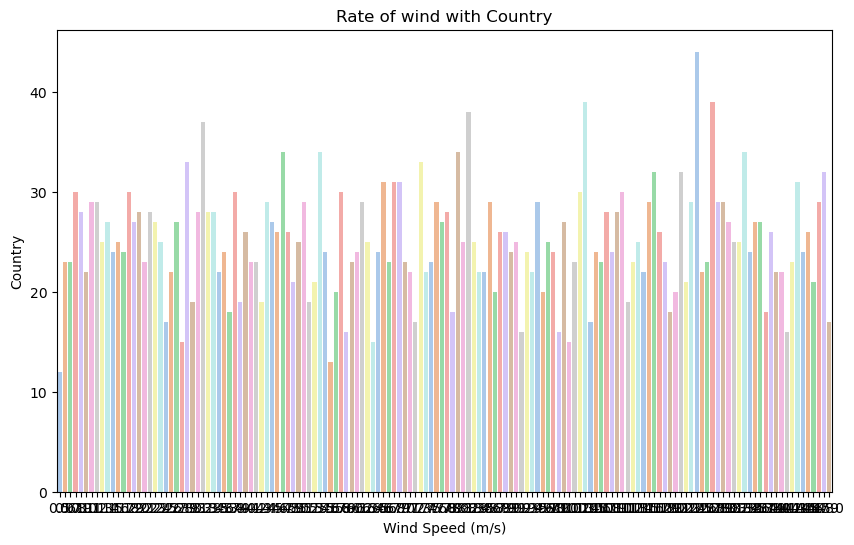

In [18]:
#Univariate Graph
#2.Countplot of Genre
plt.figure(figsize=(10,6))
sns.countplot(x='Wind Speed (m/s)', data=df, palette='pastel')
plt.title('Rate of wind with Country')
plt.ylabel('Country')
plt.show()

In [19]:
#Bivariate Graph
#3.Scatter Plot
plt.scatter(df ['Temperature (°C)'], df['Humidity (%)'], color='green')
plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.show()

KeyError: 'Temperature (°C)'

In [ ]:
#Univariate Graph
#4. Boxplot of Annual Income by Genre (Gender)
plt.figure(figsize=(8,5))
sns.boxplot(x='City', y='AQI', data=df, palette='Set3')
plt.title('City wise air quality index')
plt.show()

In [ ]:
#5. Bivariate graph
sns.set_palette("Pastel1")
plt.figure(figsize=(8, 4))
sns.pairplot(df)
plt.suptitle('Pair Plot')
plt.show()